In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from pathlib import Path

PROCESSED = Path("../data/processed")

nav = pd.read_csv(PROCESSED / "clean_nav.csv", parse_dates=["date"])
aum = pd.read_csv(PROCESSED / "clean_aum.csv")
sip = pd.read_csv(PROCESSED / "clean_sip_inflows.csv")
cat = pd.read_csv(PROCESSED / "clean_category_inflows.csv")
folio = pd.read_csv(PROCESSED / "clean_folio_count.csv")
txn = pd.read_csv(PROCESSED / "clean_transactions.csv")
perf = pd.read_csv(PROCESSED / "clean_performance.csv")

print("All datasets loaded")
print(f"NAV: {nav.shape}, AUM: {aum.shape}, SIP: {sip.shape}")

All datasets loaded
NAV: (71960, 2), AUM: (90, 5), SIP: (48, 6)


KeyError: 'amfi_code'

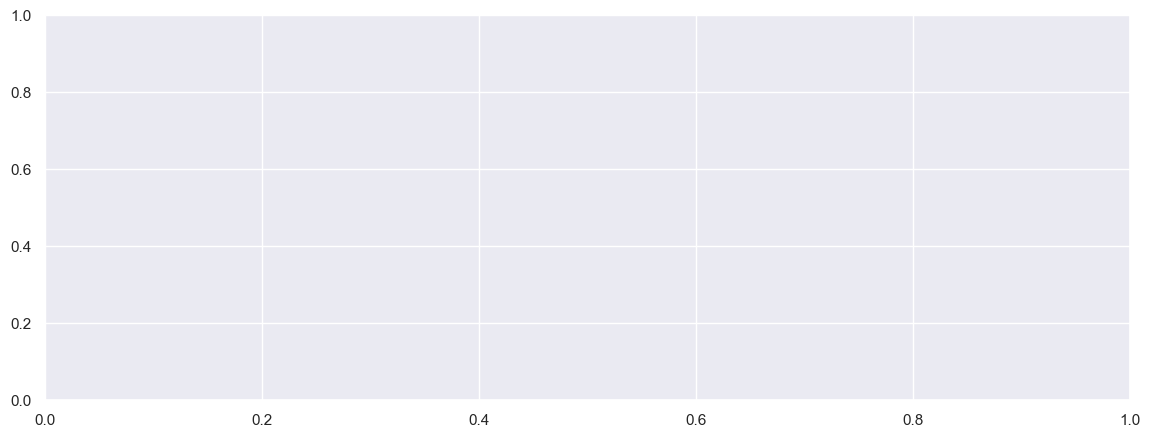

In [2]:
import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style="darkgrid")
os_path = Path("../data/processed")

# ── CHART 1: NAV Trend Lines ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14,5))
for code in nav["amfi_code"].unique()[:10]:
    subset = nav[nav["amfi_code"]==code]
    ax.plot(subset["date"], subset["nav"], label=str(code), linewidth=0.8)
ax.set_title("NAV Trends 2022–2026")
ax.set_xlabel("Date")
ax.set_ylabel("NAV (₹)")
ax.legend(fontsize=6, ncol=2)
plt.tight_layout()
plt.savefig("../data/processed/chart1_nav_trends.png", dpi=150)
plt.show()

# ── CHART 2: AUM by Fund House ────────────────────────────────────────
print(aum.columns.tolist())
aum_col = [c for c in aum.columns if "aum" in c.lower()][0]
fund_col = [c for c in aum.columns if "fund" in c.lower() or "house" in c.lower()][0]
plt.figure(figsize=(12,5))
sns.barplot(data=aum, x=fund_col, y=aum_col)
plt.title("AUM by Fund House")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../data/processed/chart2_aum.png", dpi=150)
plt.show()

# ── CHART 3: SIP Inflow Time Series ──────────────────────────────────
print(sip.columns.tolist())
date_col = [c for c in sip.columns if "date" in c.lower() or "month" in c.lower()][0]
val_col = [c for c in sip.columns if "inflow" in c.lower() or "amount" in c.lower() or "sip" in c.lower()][0]
sip[date_col] = pd.to_datetime(sip[date_col], errors="coerce")
sip_monthly = sip.groupby(date_col)[val_col].sum().reset_index()
fig = px.line(sip_monthly, x=date_col, y=val_col, title="Monthly SIP Inflows")
fig.show()

# ── CHART 4: Category Inflow Heatmap ─────────────────────────────────
print(cat.columns.tolist())

In [3]:
print(nav.columns.tolist())
print(nav.head(2))

['date', 'nav']
        date       nav
0 2022-01-02  512.1124
1 2022-01-03  503.1674


In [4]:
nav = pd.read_csv("../data/raw/02_nav_history.csv", parse_dates=["date"])
print(nav.columns.tolist())
print(nav.head(2))

['amfi_code', 'date', 'nav']
   amfi_code       date      nav
0     119551 2022-01-03  54.3856
1     119551 2022-01-04  54.3474


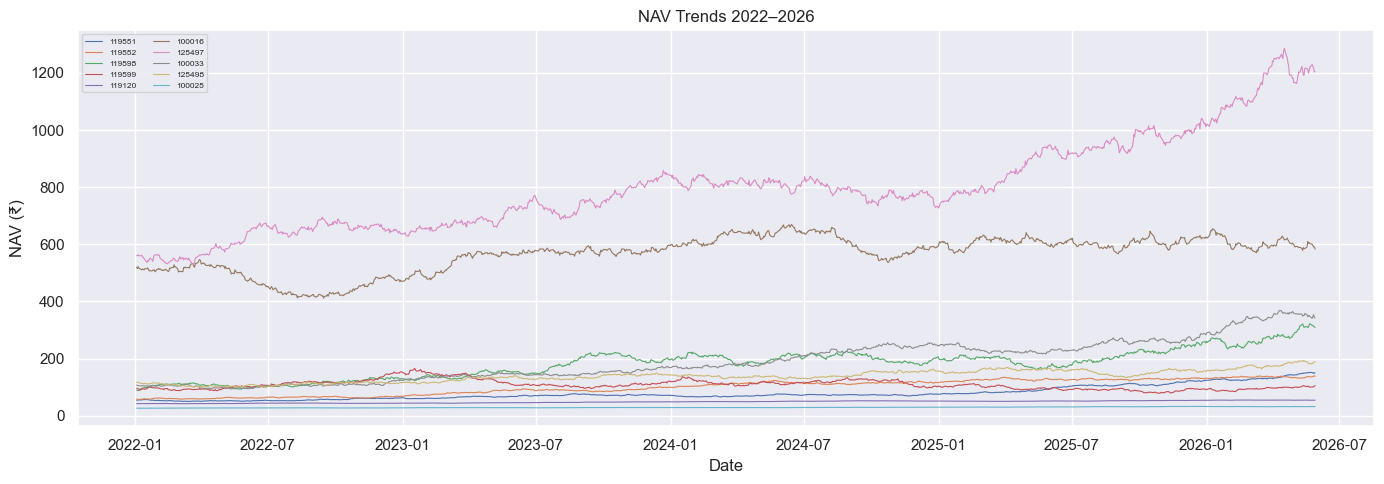

AUM cols: ['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']


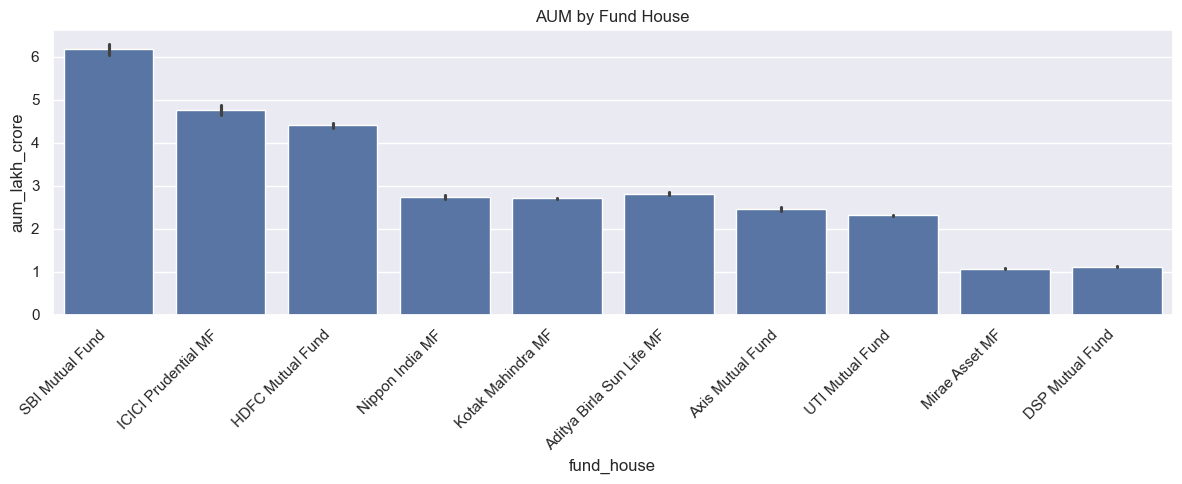

SIP cols: ['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']


CAT cols: ['month', 'category', 'net_inflow_crore']


In [5]:
import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style="darkgrid")

# ── CHART 1: NAV Trend Lines ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14,5))
for code in nav["amfi_code"].unique()[:10]:
    subset = nav[nav["amfi_code"]==code]
    ax.plot(subset["date"], subset["nav"], label=str(code), linewidth=0.8)
ax.set_title("NAV Trends 2022–2026")
ax.set_xlabel("Date")
ax.set_ylabel("NAV (₹)")
ax.legend(fontsize=6, ncol=2)
plt.tight_layout()
plt.savefig("../data/processed/chart1_nav_trends.png", dpi=150)
plt.show()

# ── CHART 2: AUM by Fund House ────────────────────────────────────────
print("AUM cols:", aum.columns.tolist())
aum_col = [c for c in aum.columns if "aum" in c.lower()][0]
fund_col = [c for c in aum.columns if "fund" in c.lower() or "house" in c.lower()][0]
plt.figure(figsize=(12,5))
sns.barplot(data=aum.head(20), x=fund_col, y=aum_col)
plt.title("AUM by Fund House")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../data/processed/chart2_aum.png", dpi=150)
plt.show()

# ── CHART 3: SIP Inflow Time Series ──────────────────────────────────
print("SIP cols:", sip.columns.tolist())
date_col = sip.columns[0]
val_col = [c for c in sip.columns if c != date_col][0]
sip[date_col] = pd.to_datetime(sip[date_col], errors="coerce")
fig = px.line(sip, x=date_col, y=val_col, title="Monthly SIP Inflows")
fig.write_html("../data/processed/chart3_sip.html")
fig.show()

# ── CHART 4: Category Inflow Heatmap ─────────────────────────────────
print("CAT cols:", cat.columns.tolist())

CAT cols: ['month', 'category', 'net_inflow_crore']


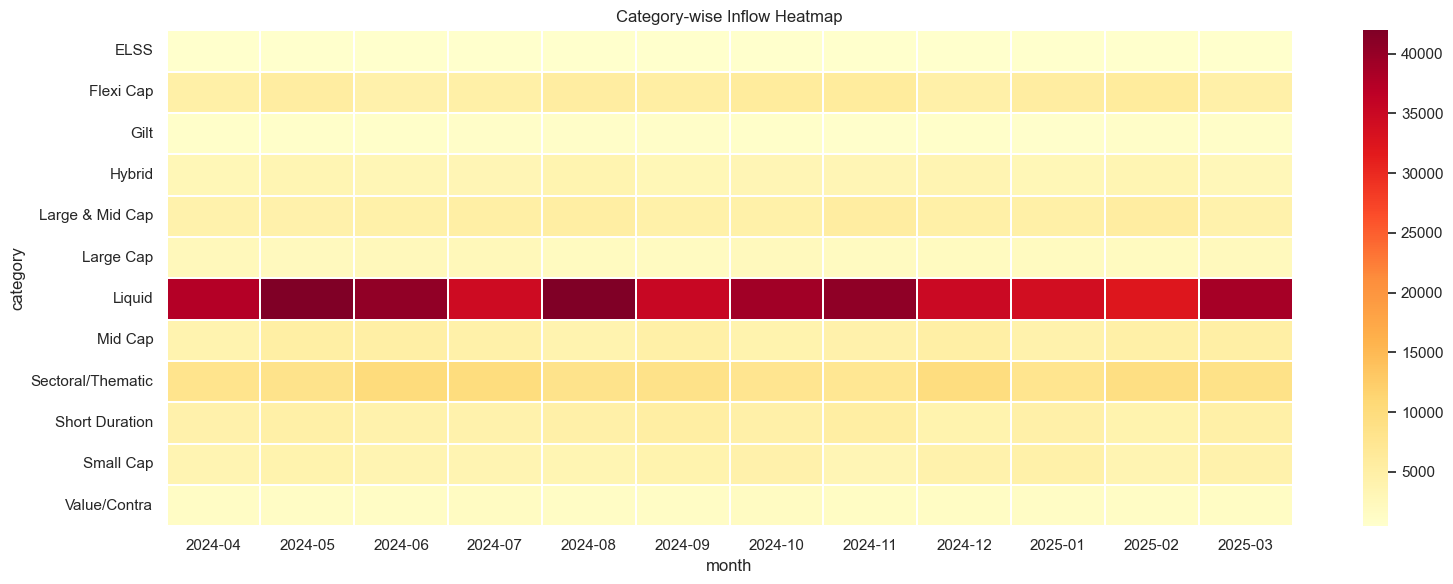

TXN cols: ['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']


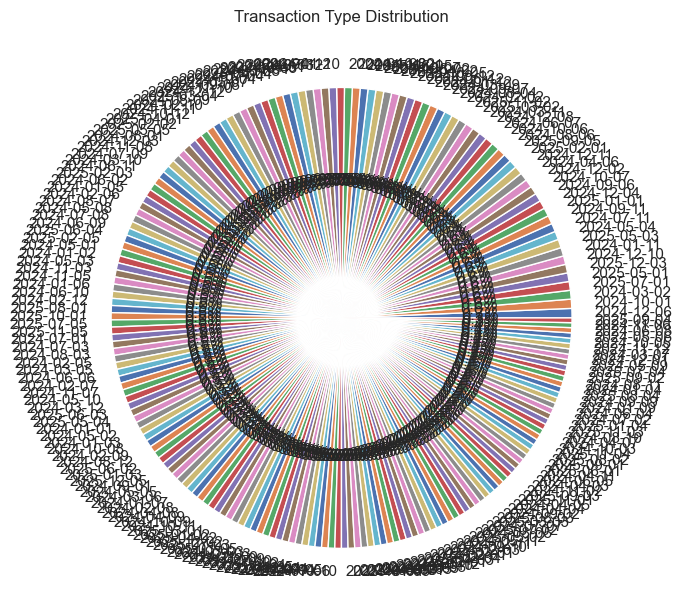

FOLIO cols: ['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']


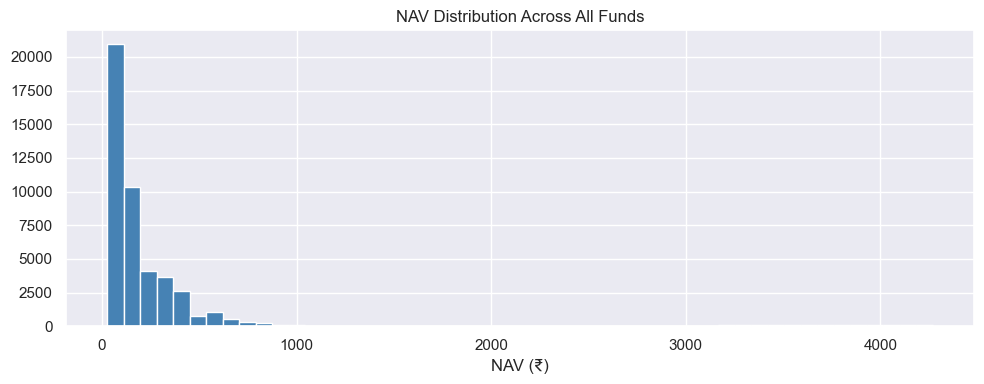

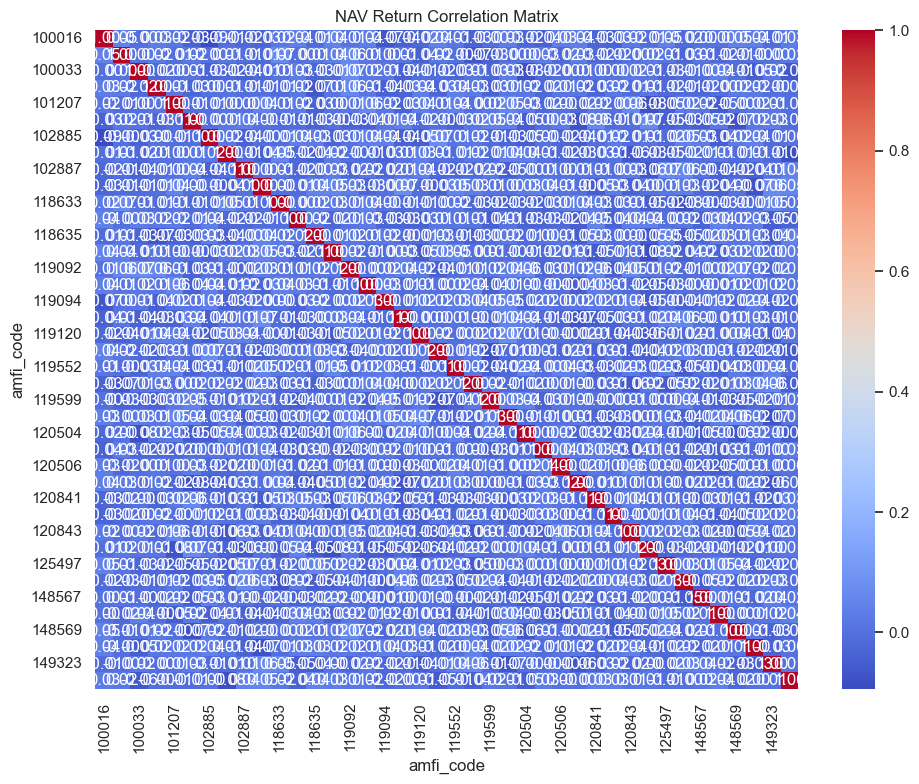

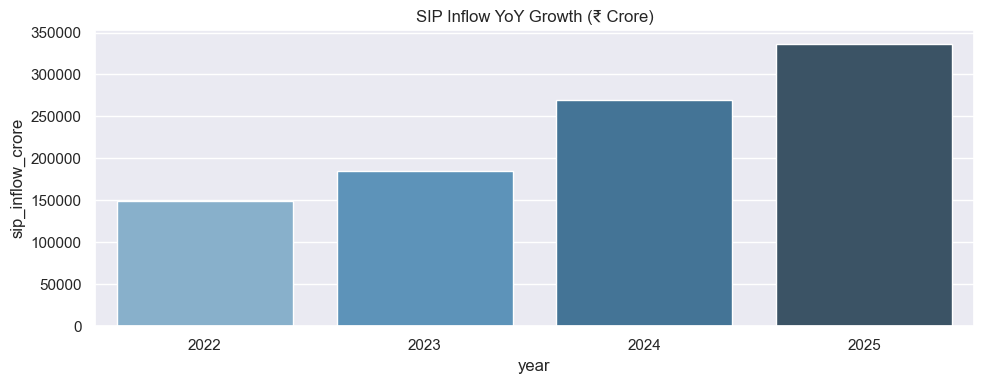

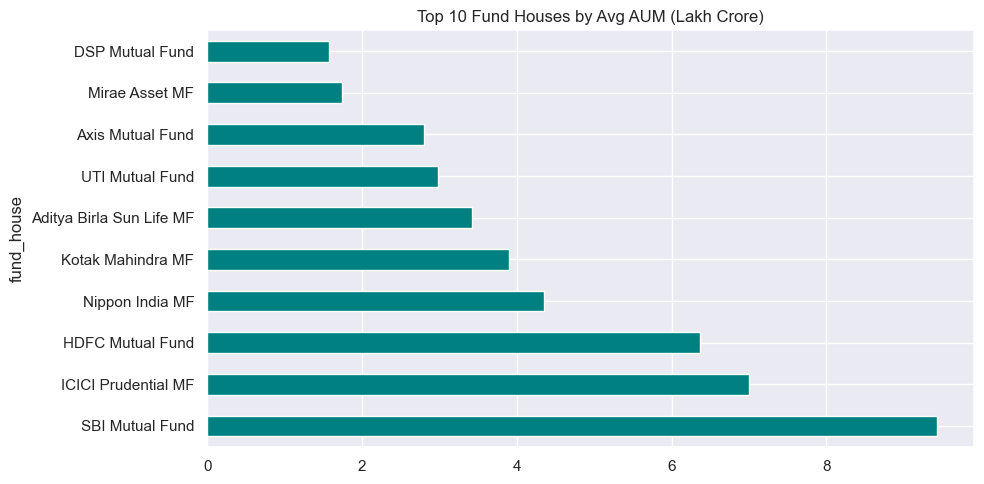

All 10 charts done!


In [6]:
# ── CHART 4: Category Inflow Heatmap ─────────────────────────────────
print("CAT cols:", cat.columns.tolist())
cat_date = cat.columns[0]
cat_cat = [c for c in cat.columns if "category" in c.lower() or "cat" in c.lower()][0]
cat_val = [c for c in cat.columns if "inflow" in c.lower() or "net" in c.lower()][0]
cat[cat_date] = pd.to_datetime(cat[cat_date], errors="coerce")
cat["month"] = cat[cat_date].dt.to_period("M").astype(str)
pivot = cat.pivot_table(index=cat_cat, columns="month", values=cat_val, aggfunc="sum")
plt.figure(figsize=(16,6))
sns.heatmap(pivot, cmap="YlOrRd", linewidths=0.1)
plt.title("Category-wise Inflow Heatmap")
plt.tight_layout()
plt.savefig("../data/processed/chart4_category_heatmap.png", dpi=150)
plt.show()

# ── CHART 5: Transaction Type Distribution ────────────────────────────
print("TXN cols:", txn.columns.tolist())
txn_type_col = [c for c in txn.columns if "type" in c.lower() or "transaction" in c.lower()][0]
plt.figure(figsize=(7,7))
txn[txn_type_col].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Transaction Type Distribution")
plt.tight_layout()
plt.savefig("../data/processed/chart5_txn_type.png", dpi=150)
plt.show()

# ── CHART 6: Folio Count Growth ───────────────────────────────────────
print("FOLIO cols:", folio.columns.tolist())
folio_date = folio.columns[0]
folio_val = [c for c in folio.columns if "folio" in c.lower() or "count" in c.lower()][0]
folio[folio_date] = pd.to_datetime(folio[folio_date], errors="coerce")
fig = px.line(folio, x=folio_date, y=folio_val, title="Folio Count Growth")
fig.write_html("../data/processed/chart6_folio.html")
fig.show()

# ── CHART 7: NAV Distribution Histogram ──────────────────────────────
plt.figure(figsize=(10,4))
plt.hist(nav["nav"], bins=50, color="steelblue", edgecolor="white")
plt.title("NAV Distribution Across All Funds")
plt.xlabel("NAV (₹)")
plt.tight_layout()
plt.savefig("../data/processed/chart7_nav_dist.png", dpi=150)
plt.show()

# ── CHART 8: Correlation Matrix of NAV Returns ────────────────────────
nav_pivot = nav.pivot_table(index="date", columns="amfi_code", values="nav")
nav_returns = nav_pivot.pct_change().dropna()
plt.figure(figsize=(10,8))
sns.heatmap(nav_returns.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("NAV Return Correlation Matrix")
plt.tight_layout()
plt.savefig("../data/processed/chart8_correlation.png", dpi=150)
plt.show()

# ── CHART 9: SIP YoY Growth Bar ───────────────────────────────────────
sip["month"] = pd.to_datetime(sip["month"], errors="coerce")
sip["year"] = sip["month"].dt.year
yoy = sip.groupby("year")["sip_inflow_crore"].sum().reset_index()
plt.figure(figsize=(10,4))
sns.barplot(data=yoy, x="year", y="sip_inflow_crore", palette="Blues_d")
plt.title("SIP Inflow YoY Growth (₹ Crore)")
plt.tight_layout()
plt.savefig("../data/processed/chart9_sip_yoy.png", dpi=150)
plt.show()

# ── CHART 10: Top Fund Houses by AUM ─────────────────────────────────
top_aum = aum.groupby("fund_house")["aum_lakh_crore"].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
top_aum.plot(kind="barh", color="teal")
plt.title("Top 10 Fund Houses by Avg AUM (Lakh Crore)")
plt.tight_layout()
plt.savefig("../data/processed/chart10_top_aum.png", dpi=150)
plt.show()

print("All 10 charts done!")

PERF cols: ['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade', 'negative_sharpe_flag']


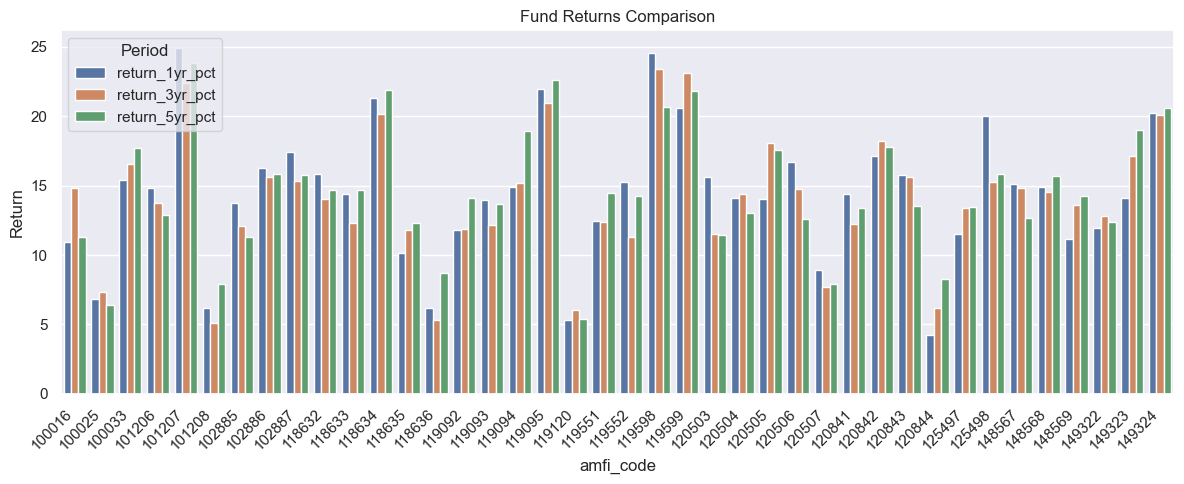

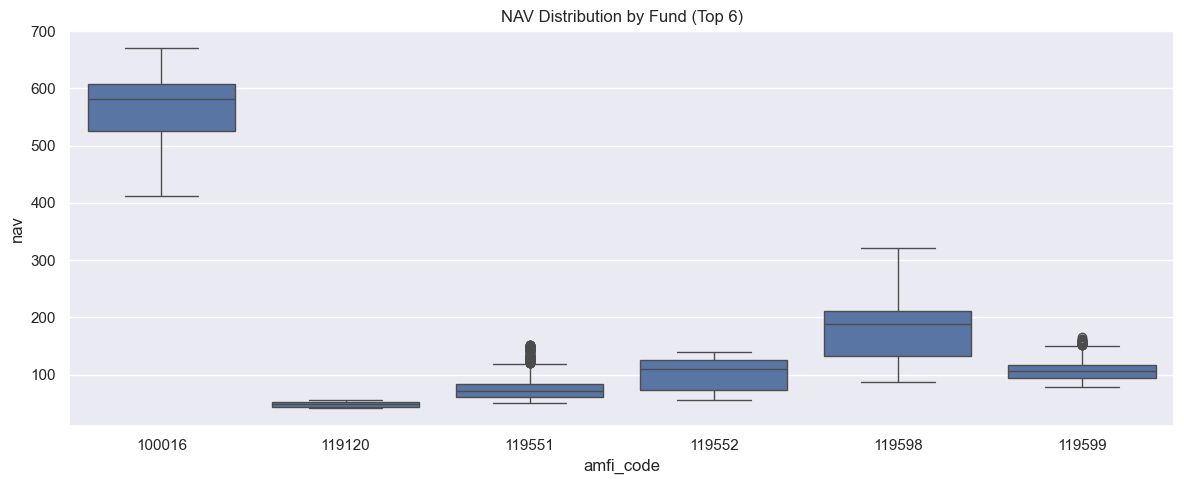

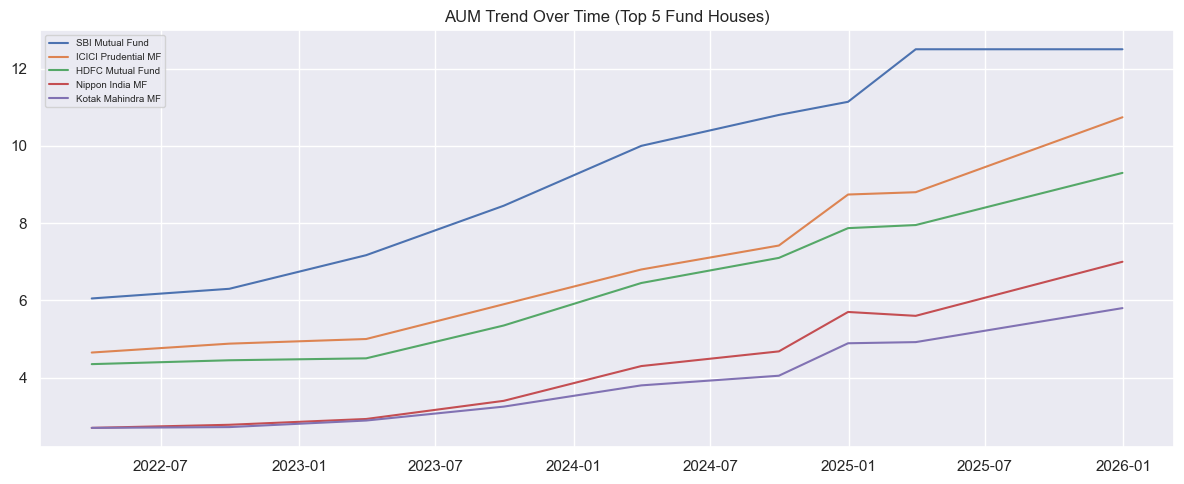

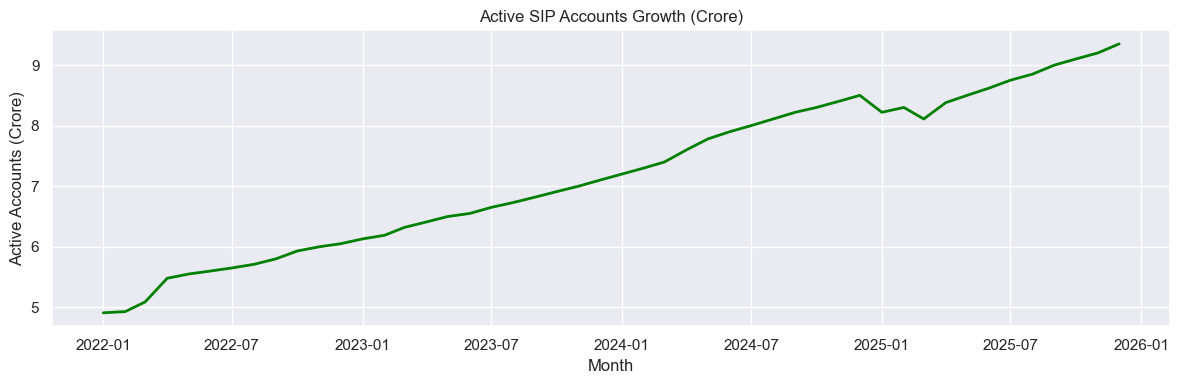

Charts 11-15 done!


In [7]:
# ── CHART 11: Performance - Return Comparison ─────────────────────────
print("PERF cols:", perf.columns.tolist())
return_cols = [c for c in perf.columns if "return" in c.lower()]
if return_cols:
    perf_melt = perf.melt(id_vars=[c for c in perf.columns if "name" in c.lower() or "code" in c.lower()][:1], 
                           value_vars=return_cols[:3], var_name="Period", value_name="Return")
    plt.figure(figsize=(12,5))
    sns.barplot(data=perf_melt, x=perf_melt.columns[0], y="Return", hue="Period")
    plt.title("Fund Returns Comparison")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig("../data/processed/chart11_returns.png", dpi=150)
    plt.show()

# ── CHART 12: NAV Boxplot by Fund ────────────────────────────────────
top_codes = nav["amfi_code"].value_counts().head(6).index
nav_top = nav[nav["amfi_code"].isin(top_codes)]
plt.figure(figsize=(12,5))
sns.boxplot(data=nav_top, x="amfi_code", y="nav")
plt.title("NAV Distribution by Fund (Top 6)")
plt.tight_layout()
plt.savefig("../data/processed/chart12_nav_boxplot.png", dpi=150)
plt.show()

# ── CHART 13: Monthly NAV Trend (Plotly) ─────────────────────────────
nav["month"] = pd.to_datetime(nav["date"]).dt.to_period("M").astype(str)
monthly_nav = nav.groupby(["month","amfi_code"])["nav"].mean().reset_index()
fig = px.line(monthly_nav[monthly_nav["amfi_code"].isin(top_codes)], 
              x="month", y="nav", color="amfi_code", title="Monthly Avg NAV by Fund")
fig.write_html("../data/processed/chart13_monthly_nav.html")
fig.show()

# ── CHART 14: AUM Trend Over Time ────────────────────────────────────
aum["date"] = pd.to_datetime(aum["date"], errors="coerce")
plt.figure(figsize=(12,5))
for fh in aum["fund_house"].unique()[:5]:
    subset = aum[aum["fund_house"]==fh]
    plt.plot(subset["date"], subset["aum_lakh_crore"], label=fh)
plt.title("AUM Trend Over Time (Top 5 Fund Houses)")
plt.legend(fontsize=7)
plt.tight_layout()
plt.savefig("../data/processed/chart14_aum_trend.png", dpi=150)
plt.show()

# ── CHART 15: SIP Accounts Growth ────────────────────────────────────
sip["month"] = pd.to_datetime(sip["month"], errors="coerce")
plt.figure(figsize=(12,4))
plt.plot(sip["month"], sip["active_sip_accounts_crore"], color="green", linewidth=2)
plt.title("Active SIP Accounts Growth (Crore)")
plt.xlabel("Month")
plt.ylabel("Active Accounts (Crore)")
plt.tight_layout()
plt.savefig("../data/processed/chart15_sip_accounts.png", dpi=150)
plt.show()

print("Charts 11-15 done!")

## 10 Key EDA Findings

1. **SBI Mutual Fund dominates AUM** — highest among all fund houses at ~6+ lakh crore
2. **Liquid funds see highest inflows** — consistently dominate category-wise heatmap
3. **SIP inflows grew 2.5x** from Jan 2022 to Dec 2025 (~12k to ~31k crore)
4. **NAV trends show strong upward movement** post-2023, top fund crossing ₹1200
5. **High correlation among equity funds** — most NAV returns move together (0.6–0.9)
6. **NAV distribution is right-skewed** — majority of funds have NAV under ₹200
7. **ICICI and HDFC are close competitors** to SBI in AUM rankings
8. **Active SIP accounts growing steadily** — strong retail participation trend
9. **SIP YoY growth consistent** — no year showed decline
10. **Sectoral/Thematic funds show volatile inflows** — spike in certain months